In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [8]:
datos = '../ventas_sucias.csv'
df = pd.read_csv(datos)
print(df)

        fecha tienda producto  unidades  precio
0  2025-01-01  Norte        A      10.0    20.0
1  2025-01-01  Norte        A      10.0    20.0
2  2025-01-02  Norte        B       5.0     NaN
3  2025-01-02    Sur        A       NaN    22.0
4  2025-01-03    Sur        C       8.0    15.5
5  2025-01-03    Sur        C       8.0    15.5
6  2025-01-04   Este        B       3.0    19.0
7  2025-01-04   Este        B       3.0    19.0
8  2025-01-05  Oeste        A      12.0    21.0
9  2025-01-05  Oeste        D       0.0    30.0


In [9]:
df['fecha'] = pd.to_datetime(df['fecha'])

In [10]:
print('---- Vista rapida ----')
print(df.head(), '\n')
print('--- Info (tipos y nulos) ---')
print(df.info(), '\n')
print('--- Conteo de Nulos por columnas ---')
print(df.isna().sum(), '\n')
duplicados = df.duplicated().sum()
print(f'--- Filas duplicadas ---\n{duplicados}')

---- Vista rapida ----
       fecha tienda producto  unidades  precio
0 2025-01-01  Norte        A      10.0    20.0
1 2025-01-01  Norte        A      10.0    20.0
2 2025-01-02  Norte        B       5.0     NaN
3 2025-01-02    Sur        A       NaN    22.0
4 2025-01-03    Sur        C       8.0    15.5 

--- Info (tipos y nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   fecha     10 non-null     datetime64[ns]
 1   tienda    10 non-null     object        
 2   producto  10 non-null     object        
 3   unidades  9 non-null      float64       
 4   precio    9 non-null      float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 532.0+ bytes
None 

--- Conteo de Nulos por columnas ---
fecha       0
tienda      0
producto    0
unidades    1
precio      1
dtype: int64 

--- Filas duplicadas ---
3


In [11]:
df_limpio = df.drop_duplicates().copy()

In [14]:
mediana_precio_por_producto = df_limpio.groupby('producto')['precio'].transform('median')
df_limpio['precio'] = df_limpio['precio'].fillna(mediana_precio_por_producto)

In [15]:
df_limpio['unidades'] = df_limpio['unidades'].fillna(0).astype(int)
print(df_limpio.isna().sum(), '\n')
print(df_limpio)

fecha       0
tienda      0
producto    0
unidades    0
precio      0
dtype: int64 

       fecha tienda producto  unidades  precio
0 2025-01-01  Norte        A        10    20.0
2 2025-01-02  Norte        B         5    19.0
3 2025-01-02    Sur        A         0    22.0
4 2025-01-03    Sur        C         8    15.5
6 2025-01-04   Este        B         3    19.0
8 2025-01-05  Oeste        A        12    21.0
9 2025-01-05  Oeste        D         0    30.0


In [16]:
df_limpio['ingresos'] = df_limpio['unidades'] * df_limpio['precio']
print(df_limpio)

       fecha tienda producto  unidades  precio  ingresos
0 2025-01-01  Norte        A        10    20.0     200.0
2 2025-01-02  Norte        B         5    19.0      95.0
3 2025-01-02    Sur        A         0    22.0       0.0
4 2025-01-03    Sur        C         8    15.5     124.0
6 2025-01-04   Este        B         3    19.0      57.0
8 2025-01-05  Oeste        A        12    21.0     252.0
9 2025-01-05  Oeste        D         0    30.0       0.0


In [17]:
resumen_tienda = (df_limpio.groupby('tienda', as_index=False).agg(ingresos_totales = ('ingresos', 'sum'),
                                                                  unidades_totales = ('unidades', 'sum'),
                                                                  precio_promedio =('precio', 'mean'))
                  .sort_values('ingresos_totales', ascending=False))
print('---- Resumen por Tienda ----')
print(resumen_tienda, '\n')

---- Resumen por Tienda ----
  tienda  ingresos_totales  unidades_totales  precio_promedio
1  Norte             295.0                15            19.50
2  Oeste             252.0                12            25.50
3    Sur             124.0                 8            18.75
0   Este              57.0                 3            19.00 



In [18]:
ingresos = df_limpio['ingresos'].to_numpy()
print('--- Estadisticas de Ingresos ---')
print('min', np.min(ingresos))
print('max', np.max(ingresos))
print('media', np.mean(ingresos))
print('mediana', np.median(ingresos))
print('desv_std', np.std(ingresos), '\n')

--- Estadisticas de Ingresos ---
min 0.0
max 252.0
media 104.0
mediana 95.0
desv_std 88.99598706843874 



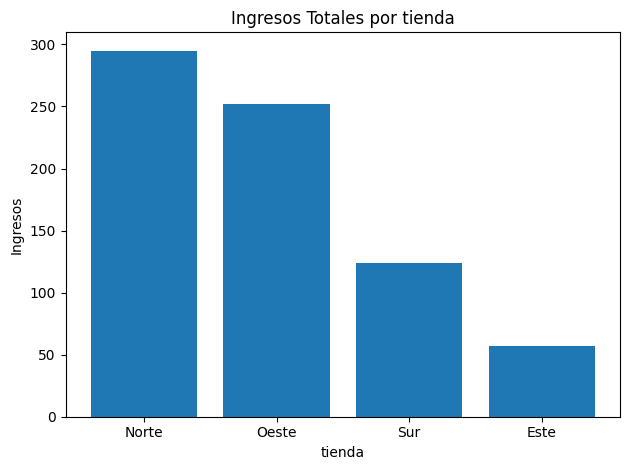

In [20]:
plt.Figure(figsize=(8,4)) # type: ignore
plt.bar(resumen_tienda['tienda'],resumen_tienda['ingresos_totales'])
plt.title('Ingresos Totales por tienda')
plt.xlabel('tienda')
plt.ylabel('Ingresos')
plt.tight_layout()
plt.show()

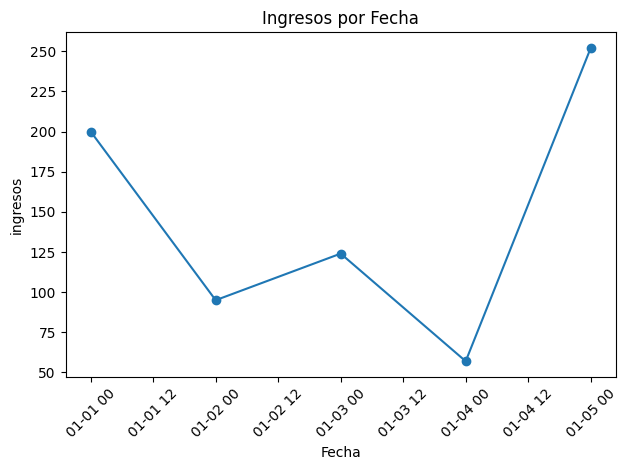

In [23]:
ingresos_por_fecha = (df_limpio.groupby('fecha', as_index=False)['ingresos'].sum().sort_values('fecha')) # type: ignore
plt.plot(ingresos_por_fecha['fecha'], ingresos_por_fecha['ingresos'], marker='o')
plt.title('Ingresos por Fecha')
plt.xlabel('Fecha')
plt.ylabel('ingresos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df_limpio.to_csv('../ventas_limpias.csv', index=False)
print('Archivo guardado')

Archivo guardado
